In [ ]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [62]:
# Init SegFormer
processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device) # move to gpu if available

# Model from https://huggingface.co/mattmdjaga/segformer_b2_clothes
# Model trained on ATR Data set
# https://github.com/lemondan/HumanParsing-Dataset

SHIRT_LABEL = 4

class_labels = "" \
"""background     0
hat            1
hair           2 
sunglass       3
upper-clothes  4
skirt          5
pants          6
dress          7
belt           8
left-shoe      9
right-shoe     10
face           11
left-leg       12
right-leg      13
left-arm       14
right-arm      15
bag            16
scarf          17"""


In [67]:
# Get input images
image1 = Image.open("./data/seg_test_1.jpg")
image2 = Image.open("./data/seg_test_2.jpg")

inputs = processor(images=[image1, image2], return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()} # move input tensors to gpu if available

In [69]:
print(f"Size of input image [batch_size, rgb_channels, height, width]: {inputs['pixel_values'].shape}")

Size of input image [batch_size, rgb_channels, height, width]: torch.Size([2, 3, 512, 512])


In [ ]:
# Run inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # still on gpu

# Upsample to original image size
upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)

# For each pixel, see what class has the highest probability
# pred_seg = upsampled_logits.argmax(dim=1).cpu()

# Create a boolean mask of areas where "shirt" is the top class
pred_classes = upsampled_logits.argmax(dim=1)
shirt_mask = (pred_classes == SHIRT_LABEL).int()

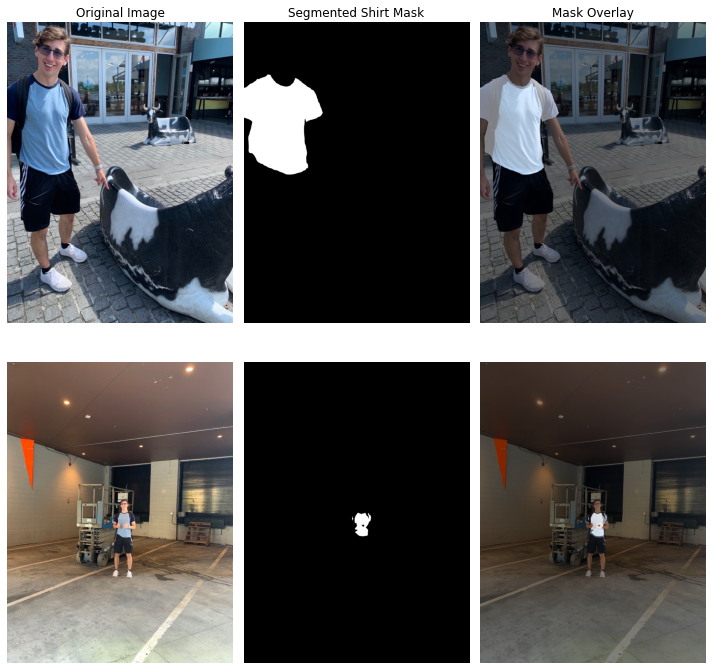

In [79]:
# Visualize the mask

shirt_mask = shirt_mask.cpu() # move to cpu before visualization

fig, axes = plt.subplots(2, 3, figsize=(10, 10))

axes[0, 0].imshow(image1)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(shirt_mask[0], cmap="gray")
axes[0, 1].set_title("Segmented Shirt Mask")
axes[0, 1].axis("off")

axes[0, 2].imshow(image1)
axes[0, 2].imshow(shirt_mask[0], cmap="gray", alpha=0.5)
axes[0, 2].set_title("Mask Overlay")
axes[0, 2].axis("off")

axes[1, 0].imshow(image2)
axes[1, 0].axis("off")

axes[1, 1].imshow(shirt_mask[1], cmap="gray")
axes[1, 1].axis("off")

axes[1, 2].imshow(image2)
axes[1, 2].imshow(shirt_mask[1], cmap="gray", alpha=0.5)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()